# 03 - Exploratory Data Analysis

## Price Intelligence Platform

Ce notebook correspond à la phase d'analyse exploratoire. Il utilise le dataset nettoyé produit dans `02_data_cleaning.ipynb`.

**Objectifs :**

- comprendre les tendances de prix par plateforme,
- comparer les catégories,
- analyser les remises,
- observer les notes clients,
- identifier les premiers insights business,
- sauvegarder les tableaux et graphiques pour le rapport final.


## Source officielle mise à jour

Après le dernier merge, la source officielle des données est BigQuery :

```text
price-intelligence-495411.price_intelligence.products
```

Le notebook charge BigQuery en priorité. Si l'accès BigQuery n'est pas disponible dans Anaconda, il utilise un snapshot CSV exporté dans `outputs/raw_data/bigquery_products_export.csv`. Le fallback local JSON ne doit servir qu'au développement offline.


## BigQuery obligatoire

Ce notebook ne doit plus utiliser les anciens JSON locaux. La source officielle est BigQuery :

```text
price-intelligence-495411.price_intelligence.products
```

Si BigQuery n’est pas accessible depuis Anaconda, exporte la table BigQuery en CSV et place le fichier ici :

```text
C:\Users\Admin\Desktop\data-analysis\outputs\raw_data\bigquery_products_export.csv
```

Le notebook utilisera ce snapshot BigQuery. Sans accès BigQuery et sans export CSV, il s’arrêtera au lieu de reprendre les anciennes données locales.


## 1. Questions analytiques

Dans cette phase, on cherche à répondre aux questions suivantes :

1. Quelle plateforme propose les prix les plus bas ?
2. Quelle catégorie est la plus chère ?
3. Quelle plateforme contient le plus de produits ?
4. Où trouve-t-on les remises les plus importantes ?
5. Les prix varient-ils beaucoup entre catégories et plateformes ?
6. Les notes clients semblent-elles liées au prix ?

## 2. Imports et configuration

In [1]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def find_data_analysis_root():
    cwd = Path.cwd().resolve()
    candidates = [cwd, *cwd.parents]
    candidates += [candidate / "data-analysis" for candidate in candidates]
    for candidate in candidates:
        if (candidate / "price_analysis.py").exists() and (candidate / "notebooks").exists():
            return candidate.resolve()
    raise FileNotFoundError("Impossible de trouver le dossier data-analysis. Ouvre le notebook depuis data-analysis ou depuis le repo price-intelligence.")

DATA_ANALYSIS_DIR = find_data_analysis_root()
PROJECT_ROOT = DATA_ANALYSIS_DIR.parent

if str(DATA_ANALYSIS_DIR) not in sys.path:
    sys.path.insert(0, str(DATA_ANALYSIS_DIR))

import price_analysis as pa

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Dossier de travail Data Analysis :", DATA_ANALYSIS_DIR)
print("Dossier source du projet :", PROJECT_ROOT)


Dossier de travail Data Analysis : C:\Users\Admin\Desktop\price-intelligence\data-analysis
Dossier source du projet : C:\Users\Admin\Desktop\price-intelligence


## 3. Configuration de l'auto-sauvegarde

In [2]:

EXPECTED_MIN_CLEAN_ROWS = 4000
EXPECTED_MIN_STORES = 3
EXPECTED_MIN_CATEGORIES = 6
EXPECTED_STORE = "sport-direct"
EXPECTED_MIN_SCRAPE_DATE = pd.Timestamp("2026-05-19")

def assert_current_clean_dataset(df, path):
    stores = set(df.get("store", pd.Series(dtype="object")).dropna().astype(str).str.lower())
    categories = set(df.get("category", pd.Series(dtype="object")).dropna().astype(str).str.lower())
    scraped_at = pd.to_datetime(df.get("scraped_at", pd.Series(dtype="object")), errors="coerce")
    max_scrape = scraped_at.max()

    if len(df) < EXPECTED_MIN_CLEAN_ROWS:
        raise ValueError(
            f"Dataset nettoye trop petit: {len(df)} lignes seulement dans {path}. "
            "Relance 02_data_cleaning.ipynb apres BigQuery live."
        )
    if len(stores) < EXPECTED_MIN_STORES:
        raise ValueError(
            f"Dataset incomplet: seulement {len(stores)} plateformes dans {path}. "
            "Relance 02_data_cleaning.ipynb avec BigQuery live."
        )
    if EXPECTED_STORE not in stores:
        raise ValueError(
            f"Dataset nettoye stale: store {EXPECTED_STORE} absent dans {path}. "
            "Relance 02_data_cleaning.ipynb."
        )
    if len(categories) < EXPECTED_MIN_CATEGORIES:
        raise ValueError(
            f"Dataset incomplet: seulement {len(categories)} categories dans {path}. "
            "Verifie la table BigQuery et relance le nettoyage."
        )
    if pd.isna(max_scrape) or max_scrape < EXPECTED_MIN_SCRAPE_DATE:
        raise ValueError(
            f"Dataset nettoye stale: derniere date scrape = {max_scrape}. "
            "Relance 01 puis 02 avec BigQuery live."
        )


In [3]:
OUTPUTS_DIR = DATA_ANALYSIS_DIR / "outputs"
OUTPUT_TABLES = OUTPUTS_DIR / "tables"
OUTPUT_FIGURES = OUTPUTS_DIR / "figures"
OUTPUT_CLEANED = OUTPUTS_DIR / "cleaned_data"

OUTPUT_TABLES.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURES.mkdir(parents=True, exist_ok=True)
OUTPUT_CLEANED.mkdir(parents=True, exist_ok=True)

AUTO_SAVE = True

print("Auto-sauvegarde activée :", AUTO_SAVE)
print("Dossier des tableaux :", OUTPUT_TABLES)
print("Dossier des graphiques :", OUTPUT_FIGURES)

Auto-sauvegarde activée : True
Dossier des tableaux : C:\Users\Admin\Desktop\price-intelligence\data-analysis\outputs\tables
Dossier des graphiques : C:\Users\Admin\Desktop\price-intelligence\data-analysis\outputs\figures


## 4. Chargement du dataset nettoyé

In [4]:
# Chargement strict du dataset nettoye produit par le notebook 02
clean_path = OUTPUT_CLEANED / "02_clean_prices_no_outliers.csv"
full_clean_path = OUTPUT_CLEANED / "02_clean_prices_with_outlier_flag.csv"

if not clean_path.exists():
    raise FileNotFoundError(
        f"Dataset nettoye introuvable : {clean_path}. "
        "Execute d'abord 01_data_understanding.ipynb puis 02_data_cleaning.ipynb avec BigQuery live."
    )

df = pd.read_csv(clean_path)
assert_current_clean_dataset(df, clean_path)

df["scraped_at"] = pd.to_datetime(df["scraped_at"], errors="coerce")
df["scraped_date"] = pd.to_datetime(df.get("scraped_date", df["scraped_at"]), errors="coerce").dt.date

print("Dataset nettoye charge :", clean_path)
print("Nombre de lignes chargees :", len(df))
print("Plateformes :", sorted(df["store"].dropna().astype(str).str.lower().unique()))
print("Periode scrape :", df["scraped_at"].min(), "->", df["scraped_at"].max())

df.head()


Dataset nettoye charge : C:\Users\Admin\Desktop\price-intelligence\data-analysis\outputs\cleaned_data\02_clean_prices_no_outliers.csv
Nombre de lignes chargees : 6306
Plateformes : ['ebay', 'jumia', 'sport-direct']
Periode scrape : 2026-05-15 16:50:48.209635 -> 2026-05-23 13:09:10.039688


,store,category,name,price,price_before_discount,discount,stars,availability,scraped_at,scraped_date,is_price_outlier
0,ebay,racket-sports,"2Pcs WILSON Pink Tennis Balls, High Elastic Tr...",601.99,NaN,NaN,0.00,in stock,2026-05-23 13:07:39.573902,2026-05-23,False
1,ebay,racket-sports,Championship Extra-Duty XD Official Tennis Bal...,724.18,NaN,NaN,0.00,in stock,2026-05-23 13:07:39.494971,2026-05-23,False
2,ebay,racket-sports,86 Tennis Balls 4 Wilson 3 Pack Cases Are Seal...,647.41,NaN,NaN,0.00,in stock,2026-05-23 13:07:39.619165,2026-05-23,False
3,ebay,racket-sports,Tretorn Micro X Pressureless Tennis Balls Doze...,421.89,NaN,NaN,0.00,in stock,2026-05-23 13:07:39.427997,2026-05-23,False
4,ebay,racket-sports,GAMMA Quick Kids 36 Stage 3 Red Junior Tennis ...,322.45,NaN,NaN,0.00,in stock,2026-05-23 13:07:39.634264,2026-05-23,False


## 5. Vue globale du dataset nettoyé

In [5]:
print("Nombre de lignes :", df.shape[0])
print("Nombre de colonnes :", df.shape[1])
print("Plateformes :", sorted(df["store"].dropna().unique()))
print("Catégories :", sorted(df["category"].dropna().unique()))

df.info()

Nombre de lignes : 6306
Nombre de colonnes : 11
Plateformes : ['ebay', 'jumia', 'sport-direct']
Catégories : ['basketball', 'combat-sports', 'football', 'gym', 'racket-sports', 'unknown', 'volleyball']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6306 entries, 0 to 6305
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   store                  6306 non-null   object        
 1   category               6306 non-null   object        
 2   name                   6306 non-null   object        
 3   price                  6306 non-null   float64       
 4   price_before_discount  1031 non-null   float64       
 5   discount               1031 non-null   float64       
 6   stars                  6306 non-null   float64       
 7   availability           6306 non-null   object        
 8   scraped_at             6306 non-null   datetime64[ns]
 9   scraped_date           6306 non-null 

In [6]:
global_kpis = pd.DataFrame({
    "indicateur": [
        "nombre_produits",
        "nombre_plateformes",
        "nombre_categories",
        "prix_moyen",
        "prix_median",
        "prix_minimum",
        "prix_maximum",
        "ecart_type_prix",
        "remise_moyenne",
        "note_moyenne",
    ],
    "valeur": [
        len(df),
        df["store"].nunique(),
        df["category"].nunique(),
        df["price"].mean(),
        df["price"].median(),
        df["price"].min(),
        df["price"].max(),
        df["price"].std(),
        df["discount"].mean(),
        df["stars"].mean(),
    ]
})

print("KPIs globaux du dataset nettoyé :")
global_kpis

KPIs globaux du dataset nettoyé :


,indicateur,valeur
0,nombre_produits,"6,306.00"
1,nombre_plateformes,3.00
2,nombre_categories,7.00
3,prix_moyen,427.51
4,prix_median,317.74
5,prix_minimum,6.66
6,prix_maximum,"1,593.75"
7,ecart_type_prix,357.98
8,remise_moyenne,39.20
9,note_moyenne,0.34


## 6. Analyse de la couverture des produits

In [7]:
store_counts = df["store"].value_counts().reset_index()
store_counts.columns = ["plateforme", "nombre_produits"]
store_counts["part_produits"] = store_counts["nombre_produits"] / store_counts["nombre_produits"].sum()

category_counts = df["category"].value_counts().reset_index()
category_counts.columns = ["categorie", "nombre_produits"]
category_counts["part_produits"] = category_counts["nombre_produits"] / category_counts["nombre_produits"].sum()

display(store_counts)
display(category_counts)

,plateforme,nombre_produits,part_produits
0,ebay,4840,0.77
1,sport-direct,735,0.12
2,jumia,731,0.12


,categorie,nombre_produits,part_produits
0,unknown,1193,0.19
1,football,1129,0.18
2,combat-sports,1117,0.18
3,gym,1020,0.16
4,basketball,945,0.15
5,racket-sports,466,0.07
6,volleyball,436,0.07


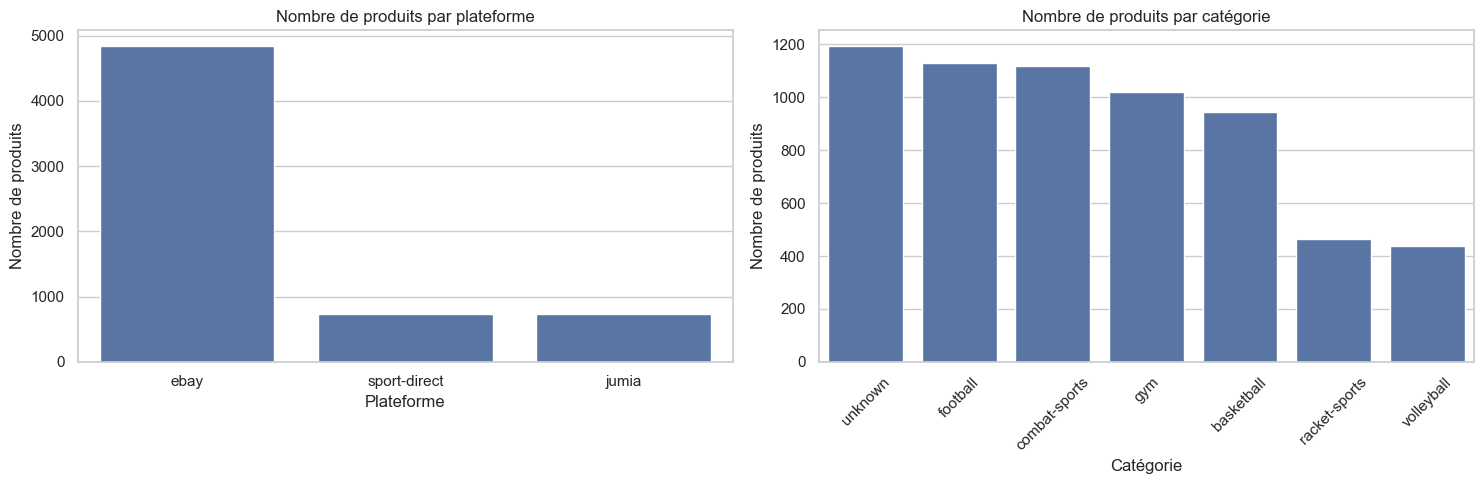

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=store_counts, x="plateforme", y="nombre_produits", ax=axes[0])
axes[0].set_title("Nombre de produits par plateforme")
axes[0].set_xlabel("Plateforme")
axes[0].set_ylabel("Nombre de produits")

sns.barplot(data=category_counts, x="categorie", y="nombre_produits", ax=axes[1])
axes[1].set_title("Nombre de produits par catégorie")
axes[1].set_xlabel("Catégorie")
axes[1].set_ylabel("Nombre de produits")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
if AUTO_SAVE:
    plt.savefig(OUTPUT_FIGURES / "03_couverture_produits.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Analyse des prix par plateforme

In [9]:
price_by_store = df.groupby("store")["price"].agg(
    nombre_produits="count",
    prix_moyen="mean",
    prix_median="median",
    prix_minimum="min",
    prix_maximum="max",
    ecart_type="std"
).reset_index().rename(columns={"store": "plateforme"})

price_by_store = price_by_store.sort_values("prix_median")
print("Statistiques des prix par plateforme :")
price_by_store

Statistiques des prix par plateforme :


,plateforme,nombre_produits,prix_moyen,prix_median,prix_minimum,prix_maximum,ecart_type
1,jumia,731,239.44,179.00,9.00,"1,591.00",227.05
2,sport-direct,735,412.40,300.00,31.25,"1,593.75",345.00
0,ebay,4840,458.21,342.16,6.66,"1,591.00",367.19


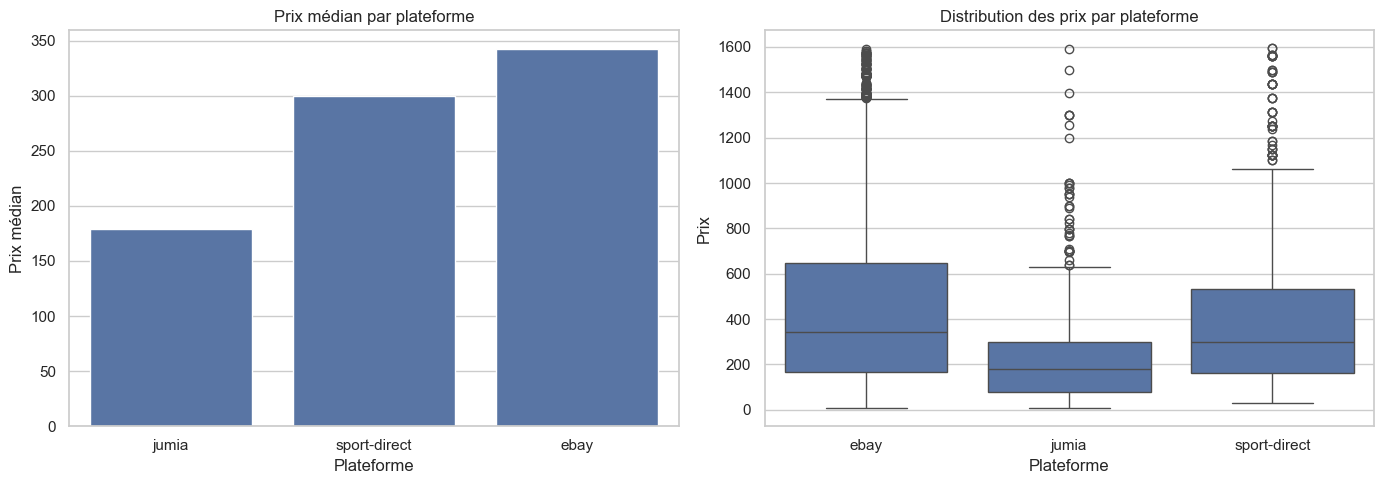

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=price_by_store, x="plateforme", y="prix_median", ax=axes[0])
axes[0].set_title("Prix médian par plateforme")
axes[0].set_xlabel("Plateforme")
axes[0].set_ylabel("Prix médian")

sns.boxplot(data=df, x="store", y="price", ax=axes[1])
axes[1].set_title("Distribution des prix par plateforme")
axes[1].set_xlabel("Plateforme")
axes[1].set_ylabel("Prix")

plt.tight_layout()
if AUTO_SAVE:
    plt.savefig(OUTPUT_FIGURES / "03_prix_par_plateforme.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Analyse des prix par catégorie

In [11]:
price_by_category = df.groupby("category")["price"].agg(
    nombre_produits="count",
    prix_moyen="mean",
    prix_median="median",
    prix_minimum="min",
    prix_maximum="max",
    ecart_type="std"
).reset_index().rename(columns={"category": "categorie"})

price_by_category = price_by_category.sort_values("prix_median", ascending=False)
print("Statistiques des prix par catégorie :")
price_by_category

Statistiques des prix par catégorie :


,categorie,nombre_produits,prix_moyen,prix_median,prix_minimum,prix_maximum,ecart_type
2,football,1129,493.87,381.47,9.16,"1,572.41",363.66
5,unknown,1193,465.76,369.81,9.16,"1,593.75",367.34
6,volleyball,436,478.70,369.73,9.16,"1,572.50",363.10
4,racket-sports,466,538.10,323.75,6.66,"1,593.75",463.74
0,basketball,945,419.35,305.25,9.16,"1,580.73",359.38
3,gym,1020,332.55,288.00,12.30,"1,591.00",249.27
1,combat-sports,1117,347.08,229.00,9.00,"1,591.00",335.15


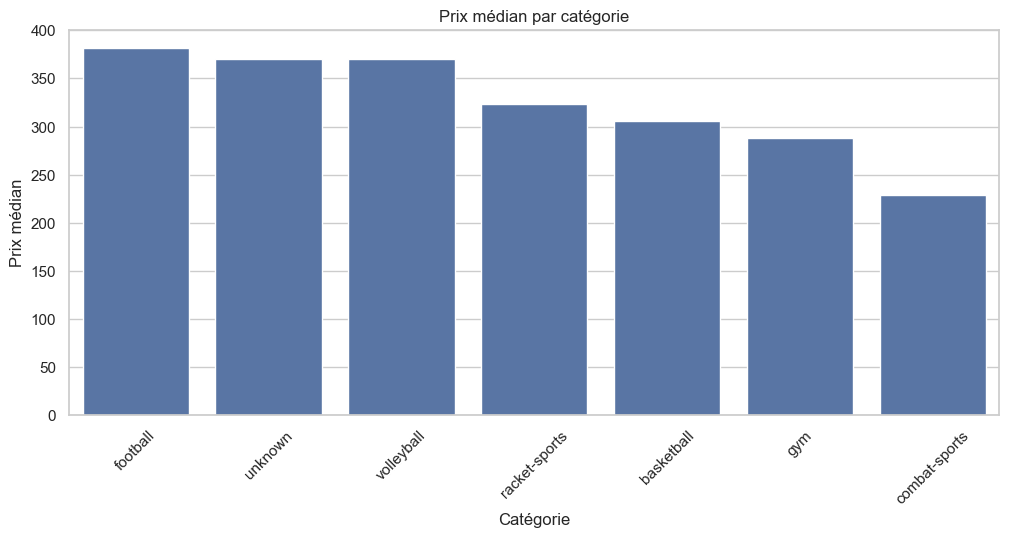

In [12]:
plt.figure(figsize=(12, 5))
sns.barplot(data=price_by_category, x="categorie", y="prix_median")
plt.title("Prix médian par catégorie")
plt.xlabel("Catégorie")
plt.ylabel("Prix médian")
plt.xticks(rotation=45)

if AUTO_SAVE:
    plt.savefig(OUTPUT_FIGURES / "03_prix_median_par_categorie.png", dpi=150, bbox_inches="tight")
plt.show()

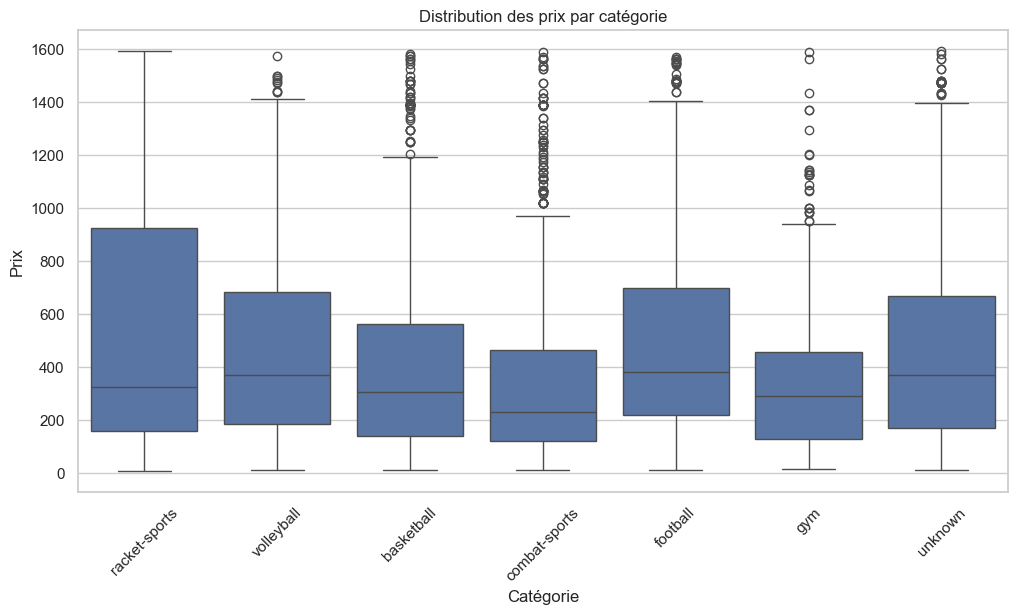

In [13]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="category", y="price")
plt.title("Distribution des prix par catégorie")
plt.xlabel("Catégorie")
plt.ylabel("Prix")
plt.xticks(rotation=45)

if AUTO_SAVE:
    plt.savefig(OUTPUT_FIGURES / "03_distribution_prix_par_categorie.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Analyse croisée plateforme x catégorie

In [14]:
pivot_median_price = df.pivot_table(
    index="category",
    columns="store",
    values="price",
    aggfunc="median"
)

print("Prix médian par catégorie et plateforme :")
pivot_median_price

Prix médian par catégorie et plateforme :


store,ebay,jumia,sport-direct
category,,,
basketball,341.79,169.00,287.50
combat-sports,277.41,89.00,162.38
football,443.91,199.00,312.44
gym,231.06,319.00,368.50
racket-sports,386.56,90.00,287.38
unknown,369.91,160.00,374.94
volleyball,396.92,173.68,687.38


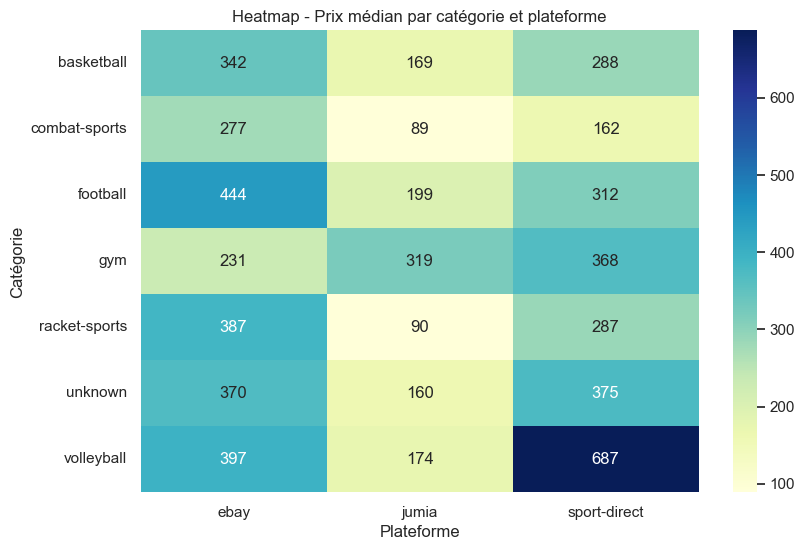

In [15]:
plt.figure(figsize=(9, 6))
sns.heatmap(pivot_median_price, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Heatmap - Prix médian par catégorie et plateforme")
plt.xlabel("Plateforme")
plt.ylabel("Catégorie")

if AUTO_SAVE:
    plt.savefig(OUTPUT_FIGURES / "03_heatmap_prix_median_store_categorie.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Analyse des remises

In [16]:
discount_df = df.dropna(subset=["discount"]).copy()

discount_by_store = discount_df.groupby("store")["discount"].agg(
    nombre_produits_avec_remise="count",
    remise_moyenne="mean",
    remise_mediane="median",
    remise_maximum="max"
).reset_index().rename(columns={"store": "plateforme"})

discount_by_category = discount_df.groupby("category")["discount"].agg(
    nombre_produits_avec_remise="count",
    remise_moyenne="mean",
    remise_mediane="median",
    remise_maximum="max"
).reset_index().rename(columns={"category": "categorie"})

display(discount_by_store.sort_values("remise_mediane", ascending=False))
display(discount_by_category.sort_values("remise_mediane", ascending=False))

,plateforme,nombre_produits_avec_remise,remise_moyenne,remise_mediane,remise_maximum
1,sport-direct,480,44.35,45.00,85.00
0,jumia,551,34.70,34.00,90.00


,categorie,nombre_produits_avec_remise,remise_moyenne,remise_mediane,remise_maximum
0,basketball,225,50.52,50.00,85.00
5,unknown,59,43.34,45.00,75.00
4,racket-sports,66,39.55,42.50,80.00
1,combat-sports,241,40.42,40.00,90.00
6,volleyball,63,40.00,37.00,75.00
2,football,215,37.13,35.00,76.00
3,gym,162,22.43,20.00,71.00


In [17]:
top_discounts = discount_df.sort_values("discount", ascending=False)[
    ["store", "category", "discount", "price", "name"]
].head(15).rename(columns={
    "store": "plateforme",
    "category": "categorie",
    "discount": "remise",
    "price": "prix",
    "name": "nom_produit"
})

print("Top 15 des remises :")
top_discounts

Top 15 des remises :


,plateforme,categorie,remise,prix,nom_produit
3206,jumia,combat-sports,90.00,49.00,Pakka COQUILLE PAKKA DE BOXE ROUGE M
3171,jumia,combat-sports,89.00,9.00,Pakka PROTEGE DENT POUR ART MARTIAUX POUR ADULTES
1595,sport-direct,basketball,85.00,75.00,Laptop Sleeve
1582,sport-direct,basketball,85.00,37.50,Ankle Sleeve With Compression Fit
3201,jumia,combat-sports,85.00,75.00,Pakka 2PCS Prot&egrave;ge tibia De thai boxing...
1654,sport-direct,basketball,85.00,31.25,Women's Basic Compression Shorts
1232,jumia,combat-sports,81.00,19.00,Protège-dents simple Shock Doctor
1683,sport-direct,basketball,80.00,62.50,Men's Series Arm Compression Sleeve
1621,sport-direct,basketball,80.00,200.00,Dnamic Compression Mens
1588,sport-direct,basketball,80.00,50.00,Women's Basic Compression Shorts


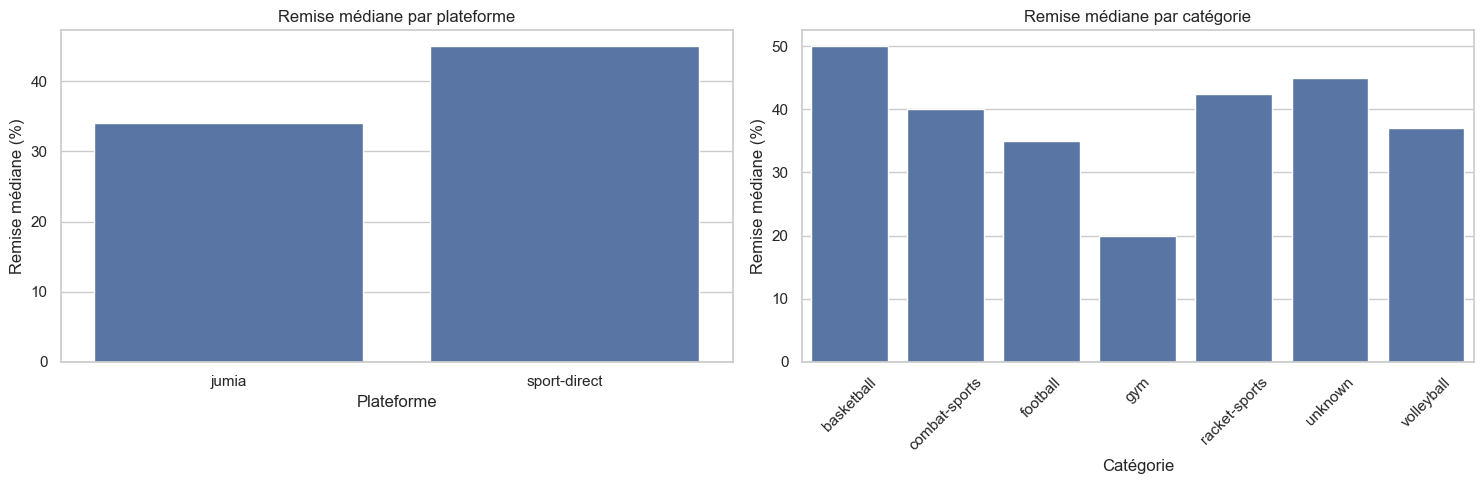

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=discount_by_store, x="plateforme", y="remise_mediane", ax=axes[0])
axes[0].set_title("Remise médiane par plateforme")
axes[0].set_xlabel("Plateforme")
axes[0].set_ylabel("Remise médiane (%)")

sns.barplot(data=discount_by_category, x="categorie", y="remise_mediane", ax=axes[1])
axes[1].set_title("Remise médiane par catégorie")
axes[1].set_xlabel("Catégorie")
axes[1].set_ylabel("Remise médiane (%)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
if AUTO_SAVE:
    plt.savefig(OUTPUT_FIGURES / "03_analyse_remises.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Analyse des notes clients

In [19]:
ratings_df = df.dropna(subset=["stars"]).copy()

rating_by_store = ratings_df.groupby("store")["stars"].agg(
    nombre_produits_notes="count",
    note_moyenne="mean",
    note_mediane="median"
).reset_index().rename(columns={"store": "plateforme"})

print("Notes clients par plateforme :")
rating_by_store

Notes clients par plateforme :


,plateforme,nombre_produits_notes,note_moyenne,note_mediane
0,ebay,4840,0.25,0.00
1,jumia,731,1.32,0.00
2,sport-direct,735,0.00,0.00


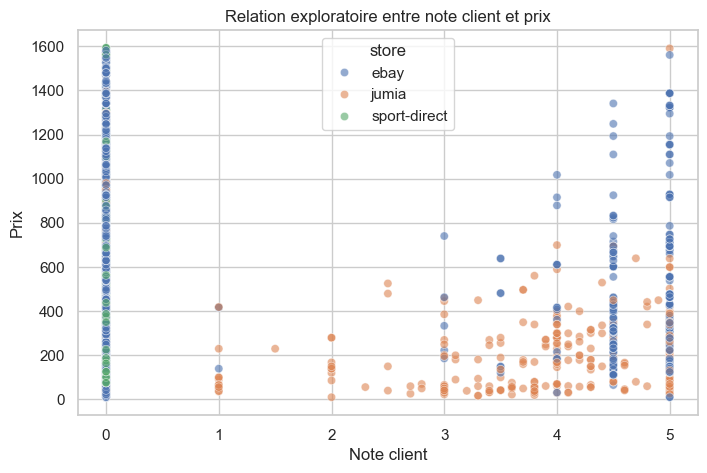

In [20]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=ratings_df, x="stars", y="price", hue="store", alpha=0.6)
plt.title("Relation exploratoire entre note client et prix")
plt.xlabel("Note client")
plt.ylabel("Prix")

if AUTO_SAVE:
    plt.savefig(OUTPUT_FIGURES / "03_relation_note_prix.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Analyse de la disponibilité

In [21]:
availability_counts = df["availability"].value_counts().reset_index()
availability_counts.columns = ["disponibilite", "nombre_produits"]

print("Répartition de la disponibilité :")
availability_counts

Répartition de la disponibilité :


,disponibilite,nombre_produits
0,in stock,5575
1,-,731


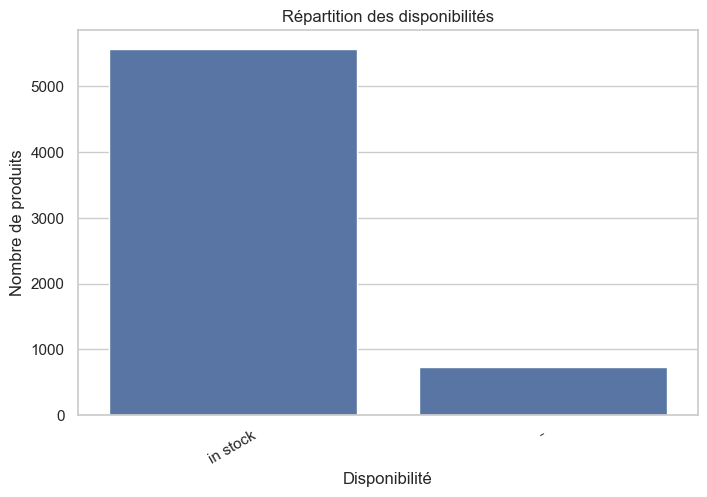

In [22]:
plt.figure(figsize=(8, 5))
sns.barplot(data=availability_counts, x="disponibilite", y="nombre_produits")
plt.title("Répartition des disponibilités")
plt.xlabel("Disponibilité")
plt.ylabel("Nombre de produits")
plt.xticks(rotation=30)

if AUTO_SAVE:
    plt.savefig(OUTPUT_FIGURES / "03_disponibilite_produits.png", dpi=150, bbox_inches="tight")
plt.show()

## 13. Synthèse automatique des premiers insights

In [23]:
cheapest_store = price_by_store.sort_values("prix_median").iloc[0]
most_expensive_store = price_by_store.sort_values("prix_median", ascending=False).iloc[0]
most_expensive_category = price_by_category.sort_values("prix_median", ascending=False).iloc[0]
largest_discount_store = discount_by_store.sort_values("remise_mediane", ascending=False).iloc[0] if len(discount_by_store) else None

eda_insights = [
    f"La plateforme avec le prix médian le plus bas est {cheapest_store['plateforme']} ({cheapest_store['prix_median']:.2f}).",
    f"La plateforme avec le prix médian le plus élevé est {most_expensive_store['plateforme']} ({most_expensive_store['prix_median']:.2f}).",
    f"La catégorie la plus chère selon le prix médian est {most_expensive_category['categorie']} ({most_expensive_category['prix_median']:.2f}).",
]

if largest_discount_store is not None:
    eda_insights.append(f"La plateforme avec la remise médiane la plus élevée est {largest_discount_store['plateforme']} ({largest_discount_store['remise_mediane']:.2f}%).")

for insight in eda_insights:
    print("-", insight)

eda_insights_df = pd.DataFrame({"insight": eda_insights})
eda_insights_df

- La plateforme avec le prix médian le plus bas est jumia (179.00).
- La plateforme avec le prix médian le plus élevé est ebay (342.16).
- La catégorie la plus chère selon le prix médian est football (381.47).
- La plateforme avec la remise médiane la plus élevée est sport-direct (45.00%).


,insight
0,La plateforme avec le prix médian le plus bas ...
1,La plateforme avec le prix médian le plus élev...
2,La catégorie la plus chère selon le prix média...
3,La plateforme avec la remise médiane la plus é...


## 14. Sauvegarde automatique des outputs EDA

In [24]:
if AUTO_SAVE:
    global_kpis.to_csv(OUTPUT_TABLES / "03_global_kpis.csv", index=False, encoding="utf-8-sig")
    store_counts.to_csv(OUTPUT_TABLES / "03_store_counts.csv", index=False, encoding="utf-8-sig")
    category_counts.to_csv(OUTPUT_TABLES / "03_category_counts.csv", index=False, encoding="utf-8-sig")
    price_by_store.to_csv(OUTPUT_TABLES / "03_price_by_store.csv", index=False, encoding="utf-8-sig")
    price_by_category.to_csv(OUTPUT_TABLES / "03_price_by_category.csv", index=False, encoding="utf-8-sig")
    pivot_median_price.to_csv(OUTPUT_TABLES / "03_pivot_median_price_store_category.csv", encoding="utf-8-sig")
    discount_by_store.to_csv(OUTPUT_TABLES / "03_discount_by_store.csv", index=False, encoding="utf-8-sig")
    discount_by_category.to_csv(OUTPUT_TABLES / "03_discount_by_category.csv", index=False, encoding="utf-8-sig")
    top_discounts.to_csv(OUTPUT_TABLES / "03_top_discounts.csv", index=False, encoding="utf-8-sig")
    rating_by_store.to_csv(OUTPUT_TABLES / "03_rating_by_store.csv", index=False, encoding="utf-8-sig")
    availability_counts.to_csv(OUTPUT_TABLES / "03_availability_counts.csv", index=False, encoding="utf-8-sig")
    eda_insights_df.to_csv(OUTPUT_TABLES / "03_eda_insights.csv", index=False, encoding="utf-8-sig")

    print("Sauvegarde EDA terminée.")
    print("Tableaux sauvegardés dans :", OUTPUT_TABLES)
    print("Graphiques sauvegardés dans :", OUTPUT_FIGURES)
else:
    print("Auto-sauvegarde désactivée.")

Sauvegarde EDA terminée.
Tableaux sauvegardés dans : C:\Users\Admin\Desktop\price-intelligence\data-analysis\outputs\tables
Graphiques sauvegardés dans : C:\Users\Admin\Desktop\price-intelligence\data-analysis\outputs\figures


## 15. Conclusion - Exploratory Analysis

À compléter après exécution du notebook :

- Plateforme la moins chère selon le prix médian :
- Plateforme la plus chère selon le prix médian :
- Catégorie la plus chère :
- Catégorie la moins chère :
- Plateforme/catégorie avec les remises les plus élevées :
- Observations sur les notes clients :
- Observations sur les disponibilités :

**Prochaine phase :** `04_statistical_tests.ipynb`, pour vérifier statistiquement les différences observées dans cette analyse exploratoire.


## 16. Analyse temporelle des prix

Cette section complète l'exigence du PDF sur les **time-series plots**. L'objectif est d'observer l'évolution du prix médian dans le temps selon la plateforme et la catégorie.

Important : si les données couvrent peu de dates de scraping, la courbe doit être interprétée comme une première lecture exploratoire, pas comme une vraie tendance long terme.


In [25]:

df_time = df.copy()
df_time["scraped_at"] = pd.to_datetime(df_time["scraped_at"], errors="coerce")
df_time = df_time.dropna(subset=["scraped_at"])
df_time["scraped_date"] = df_time["scraped_at"].dt.date

print("Nombre de lignes avec date valide :", len(df_time))
print("Nombre de dates distinctes :", df_time["scraped_date"].nunique())
print("Période couverte :", df_time["scraped_at"].min(), "->", df_time["scraped_at"].max())


Nombre de lignes avec date valide : 6306
Nombre de dates distinctes : 9
Période couverte : 2026-05-15 16:50:48.209635 -> 2026-05-23 13:09:10.039688


In [26]:

daily_price_by_store = df_time.groupby(["scraped_date", "store"])["price"].agg(
    nombre_produits="count",
    prix_moyen="mean",
    prix_median="median",
    prix_minimum="min",
    prix_maximum="max"
).reset_index().rename(columns={"store": "plateforme"})

daily_price_by_category = df_time.groupby(["scraped_date", "category"])["price"].agg(
    nombre_produits="count",
    prix_moyen="mean",
    prix_median="median",
    prix_minimum="min",
    prix_maximum="max"
).reset_index().rename(columns={"category": "categorie"})

display(daily_price_by_store.head())
display(daily_price_by_category.head())


,scraped_date,plateforme,nombre_produits,prix_moyen,prix_median,prix_minimum,prix_maximum
0,2026-05-15,ebay,737,438.81,332.91,9.16,"1,581.66"
1,2026-05-15,jumia,33,197.84,105.00,37.00,891.08
2,2026-05-16,ebay,442,448.49,336.75,9.16,"1,572.41"
3,2026-05-16,jumia,32,299.25,235.62,37.00,"1,395.00"
4,2026-05-17,ebay,822,483.04,370.00,9.16,"1,591.00"


,scraped_date,categorie,nombre_produits,prix_moyen,prix_median,prix_minimum,prix_maximum
0,2026-05-15,basketball,40,248.83,192.50,40.79,924.91
1,2026-05-15,combat-sports,56,297.45,210.44,27.66,"1,110.00"
2,2026-05-15,football,48,563.26,416.25,11.56,"1,550.67"
3,2026-05-15,gym,23,134.61,111.46,71.59,360.00
4,2026-05-15,racket-sports,24,529.78,322.69,58.18,"1,509.69"


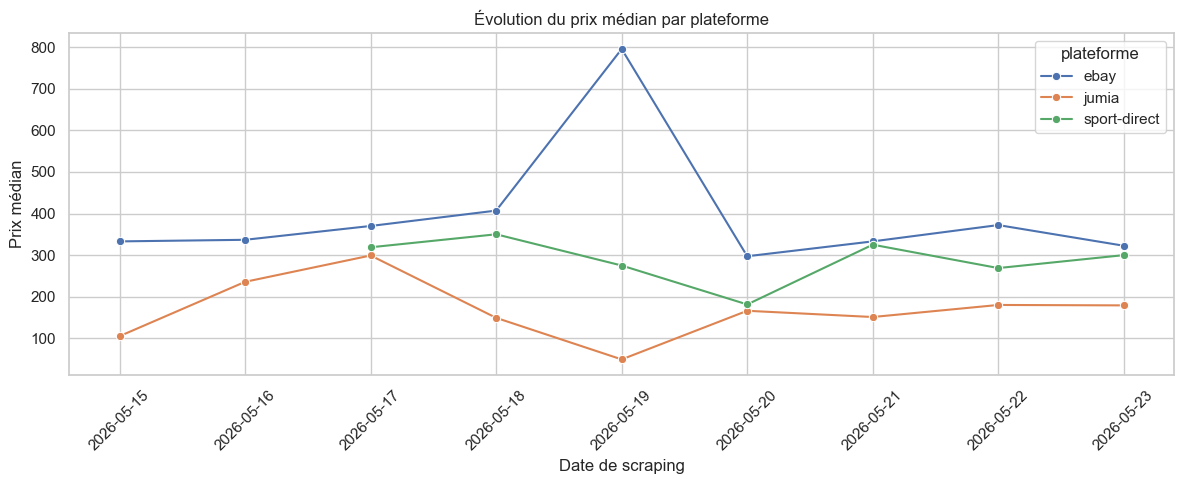

In [27]:

plt.figure(figsize=(12, 5))
sns.lineplot(data=daily_price_by_store, x="scraped_date", y="prix_median", hue="plateforme", marker="o")
plt.title("Évolution du prix médian par plateforme")
plt.xlabel("Date de scraping")
plt.ylabel("Prix médian")
plt.xticks(rotation=45)
plt.tight_layout()

if AUTO_SAVE:
    plt.savefig(OUTPUT_FIGURES / "03_time_series_prix_median_par_plateforme.png", dpi=150, bbox_inches="tight")
plt.show()


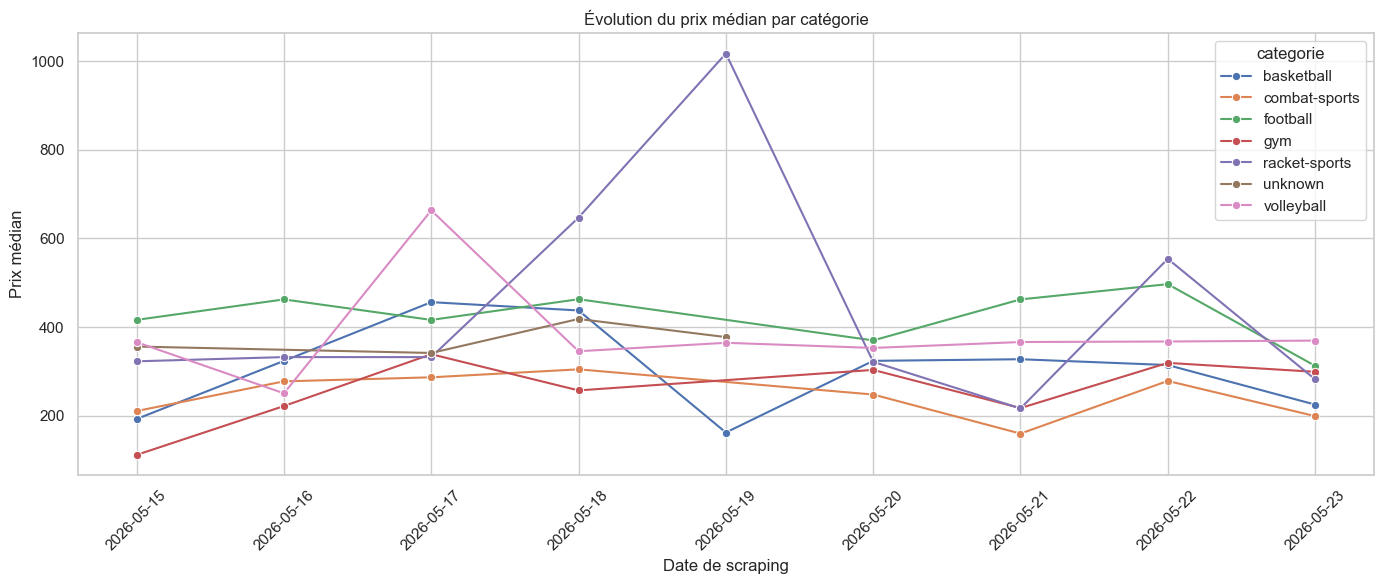

In [28]:

plt.figure(figsize=(14, 6))
sns.lineplot(data=daily_price_by_category, x="scraped_date", y="prix_median", hue="categorie", marker="o")
plt.title("Évolution du prix médian par catégorie")
plt.xlabel("Date de scraping")
plt.ylabel("Prix médian")
plt.xticks(rotation=45)
plt.tight_layout()

if AUTO_SAVE:
    plt.savefig(OUTPUT_FIGURES / "03_time_series_prix_median_par_categorie.png", dpi=150, bbox_inches="tight")
plt.show()


In [29]:

if AUTO_SAVE:
    daily_price_by_store.to_csv(OUTPUT_TABLES / "03_daily_price_by_store.csv", index=False, encoding="utf-8-sig")
    daily_price_by_category.to_csv(OUTPUT_TABLES / "03_daily_price_by_category.csv", index=False, encoding="utf-8-sig")
    print("Séries temporelles sauvegardées dans :", OUTPUT_TABLES)


Séries temporelles sauvegardées dans : C:\Users\Admin\Desktop\price-intelligence\data-analysis\outputs\tables



### Observation temporelle à intégrer au rapport

À compléter après exécution :

- Nombre de dates distinctes observées :
- Plateforme avec la tendance de prix médian la plus élevée :
- Catégorie avec la tendance de prix médian la plus élevée :
- Limite : une vraie analyse temporelle nécessite plusieurs jours/semaines de scraping.
